This project is a sales forecasting project using ml(time series).
here the future sales outcomes are predicted using the model by the present data and information.

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from datetime import datetime

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
#converts text into numbers like xxx-1 yyy-2

from sklearn.ensemble import RandomForestRegressor
#the ml model used for prediction here


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

importing required libraries for the project

In [3]:
train = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\projects\sales_data_forecasting_project\data\train.csv")

stores = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\projects\sales_data_forecasting_project\data\stores.csv")

holidays = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\projects\sales_data_forecasting_project\data\holidays_events.csv")

transactions = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\projects\sales_data_forecasting_project\data\transactions.csv")

oil = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\projects\sales_data_forecasting_project\data\oil.csv")

examine the data

check first 5 rows and to check what features they have as columns

In [4]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [5]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [6]:
holidays.head()

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


In [7]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [8]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


now we check their number of data present by using shape

In [10]:
train.shape

(3000888, 6)

In [12]:
stores.shape

(54, 5)

In [13]:
holidays.shape

(350, 6)

In [14]:
transactions.shape

(83488, 3)

In [15]:
oil.shape

(1218, 2)

now we check their daya type in order to ensure that they follow the int/float format as we cannot interpret object data types so that we can convert whichever dataset to convert into int or float

In [18]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


the train data set has columns like the id, the date of the sales, the store number, family where it refers to what category the specific item belongs,the target variable and if its on promotion or not.

we can see that date and family columns need conversions as they are in object format.

In [19]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   store_nbr  54 non-null     int64 
 1   city       54 non-null     object
 2   state      54 non-null     object
 3   type       54 non-null     object
 4   cluster    54 non-null     int64 
dtypes: int64(2), object(3)
memory usage: 2.2+ KB


In [20]:
holidays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         350 non-null    object
 1   type         350 non-null    object
 2   locale       350 non-null    object
 3   locale_name  350 non-null    object
 4   description  350 non-null    object
 5   transferred  350 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 14.1+ KB


In [21]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          83488 non-null  object
 1   store_nbr     83488 non-null  int64 
 2   transactions  83488 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.9+ MB


In [22]:
oil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        1218 non-null   object 
 1   dcoilwtico  1175 non-null   float64
dtypes: float64(1), object(1)
memory usage: 19.2+ KB


now check for the missing values

In [23]:
train.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [24]:
stores.isnull().sum()

store_nbr    0
city         0
state        0
type         0
cluster      0
dtype: int64

In [25]:
holidays.isnull().sum()

date           0
type           0
locale         0
locale_name    0
description    0
transferred    0
dtype: int64

In [26]:
transactions.isnull().sum()

date            0
store_nbr       0
transactions    0
dtype: int64

In [27]:
oil.isnull().sum()

date           0
dcoilwtico    43
dtype: int64

as we have seen already py only takes int and float but we have objects also here so the date conversion and categorical encoding is req.

In [28]:
train['date'] = pd.to_datetime(train['date'])

holidays['date'] = pd.to_datetime(holidays['date'])

transactions['date'] = pd.to_datetime(transactions['date'])

oil['date'] = pd.to_datetime(oil['date'])

In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


date is changed to datetime64 because date eventhough it is a numerical info it was shown as a text so we convert that first from obj to datetime

but we didnt change family as family's content is req for eda, if we change them to numbers now as 0 1 or etc... then they become harder to interpret as text differentiation is more easier to differentiate the various categories than the numerical ones

but after eda they will be converted to the same int/float format

next the missing values are filled with 
ffill(frwd)-msiising values get previous known values

for ffill the previous values are just copied for missing values as the cells shd no be given as blank

eg: wed-20.4 ,thurs-nan,fri-nan,sat-21.4
usually the nan values are filled with the prev days' values is 20.4 because the price might not change drastically

bfill(bkwrd)- remaining values get next known values
similar but the frwd values are given for the prev values

eg jan1-nan,jan2-nan,jan3-25,jan4-24
the automatically the jan 3 values are given for jan 1 and 2 



In [30]:
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()
oil['dcoilwtico'] = oil['dcoilwtico'].bfill()

MERGE DATA

here all the differnt data set csv files are merged together to compare together simultaneously. 
so all info should be in one table

In [31]:
#merge store
df = train.merge(
    stores,
    on='store_nbr',
    how='left'
)

In [32]:
#merge holidays
df = df.merge(
    holidays,
    on='date',
    how='left'
)

In [33]:
#merge transactions
df = df.merge(
    transactions,
    on=['date','store_nbr'],
    how='left'
)

In [34]:
#merge oil
df = df.merge(
    oil,
    on='date',
    how='left'
)

In [37]:
#cross checking
df.shape

(3054348, 17)

In [38]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred,transactions,dcoilwtico
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14


we merge by getting the common KEY column that exists on all the data sets which is store nbr in our case, and date in other cases

we can see that all the data sets are merged and found in a single table

EDA
1. Daily sales viz

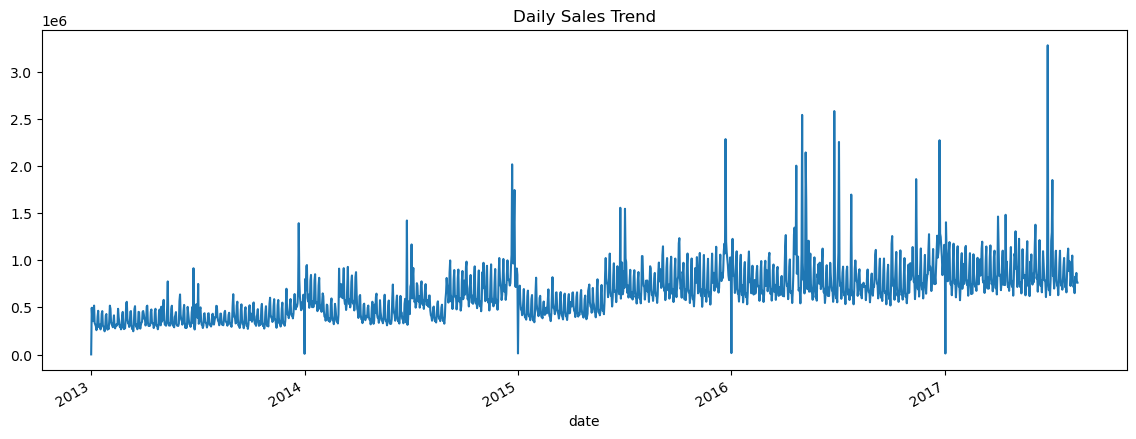

In [39]:
daily_sales = df.groupby('date')['sales'].sum()

plt.figure(figsize=(14,5))

daily_sales.plot()

plt.title('Daily Sales Trend')
plt.show()

we can analyze that the seasonal fluctuations are there but there is an increase over time 

2.Monthly sales viz

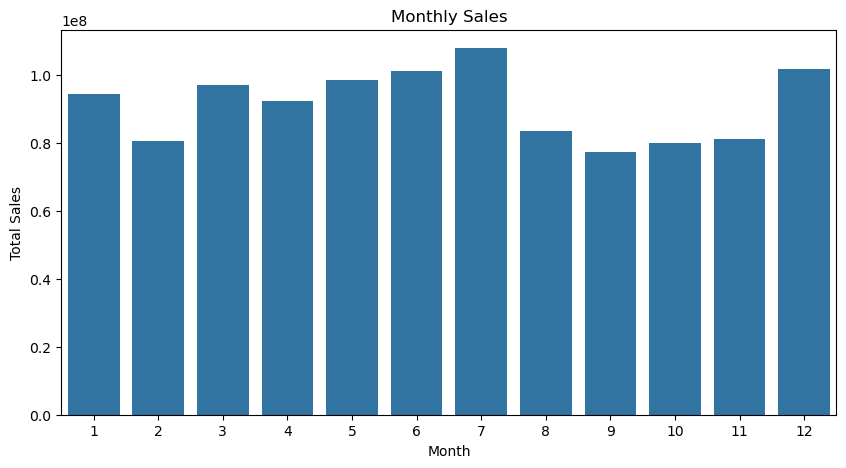

In [42]:
df['month'] = df['date'].dt.month
monthly_sales = df.groupby('month')['sales'].sum()

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title('Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.show()

maximun sales was generated in month 7-july followed by june and december

3. Store vise viz

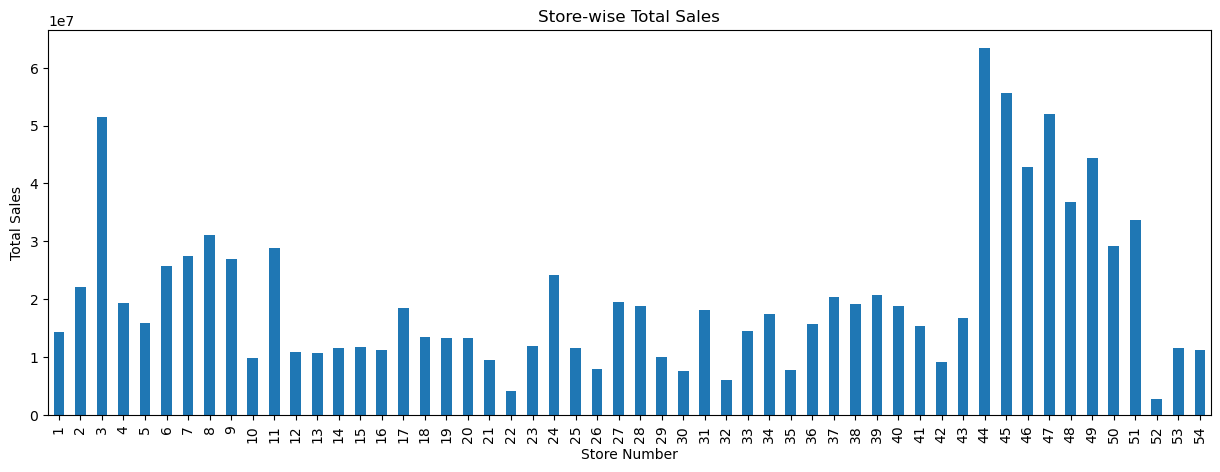

In [43]:
store_sales = df.groupby('store_nbr')['sales'].sum()
plt.figure(figsize=(15,5))

store_sales.plot(kind='bar')

plt.title('Store-wise Total Sales')
plt.xlabel('Store Number')
plt.ylabel('Total Sales')

plt.show()

stores from 44 onwards perform higher than others comparitively including store 3

4. pdt fam analysis
which product category performs well

family
GROCERY I        3.508273e+08
BEVERAGES        2.216635e+08
PRODUCE          1.254480e+08
CLEANING         9.942102e+07
DAIRY            6.582360e+07
BREAD/BAKERY     4.295992e+07
POULTRY          3.249445e+07
MEATS            3.165100e+07
PERSONAL CARE    2.510048e+07
DELI             2.458563e+07
Name: sales, dtype: float64


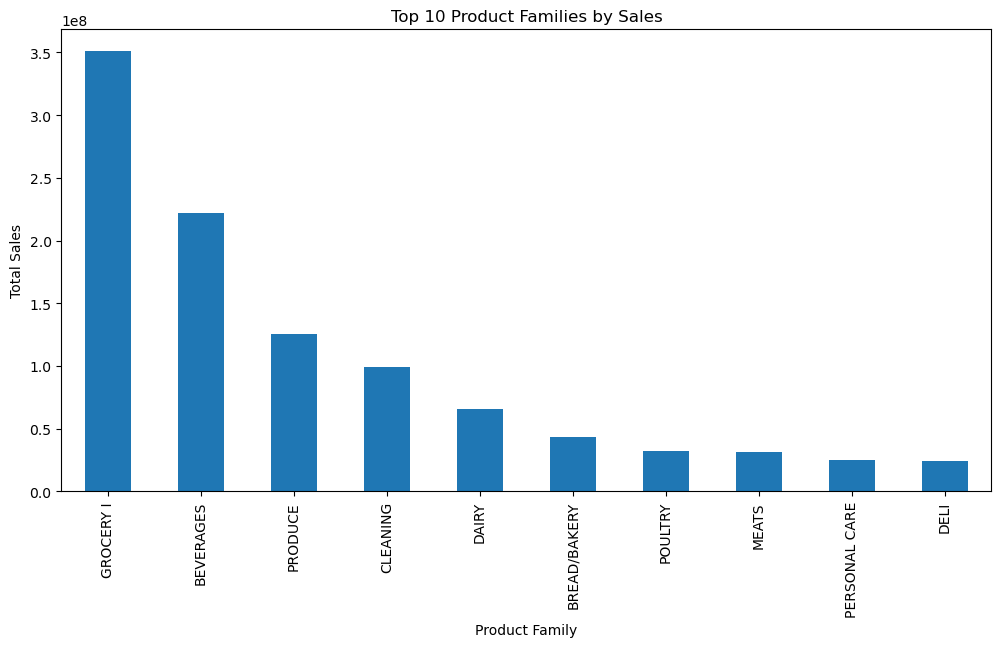

In [46]:
family_sales = df.groupby('family')['sales'].sum()
family_sales = family_sales.sort_values(
    ascending=False
)
print(family_sales.head(10))

plt.figure(figsize=(12,6))

family_sales.head(10).plot(
    kind='bar'
)

plt.title('Top 10 Product Families by Sales')
plt.xlabel('Product Family')
plt.ylabel('Total Sales')

plt.show()

5. holiday impact viz
does holiday season increase or decrease sales

is_holiday
0    352.159181
1    393.864762
Name: sales, dtype: float64


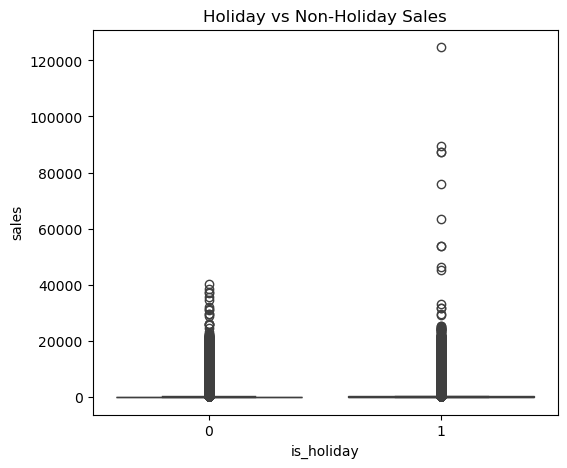

In [47]:
df['is_holiday'] = (
    df['type_y']
    .notnull()
    .astype(int)
)

holiday_sales = df.groupby(
    'is_holiday'
)['sales'].mean()

print(holiday_sales)

plt.figure(figsize=(6,5))

sns.boxplot(
    x='is_holiday',
    y='sales',
    data=df
)

plt.title('Holiday vs Non-Holiday Sales')

plt.show()

we can acknowledge that holidays does increase sales

6. promotion viz
does promotion increase the sales?


onpromotion
0    157.810472
1    469.793544
2    661.862135
3    868.014186
4    969.990576
Name: sales, dtype: float64


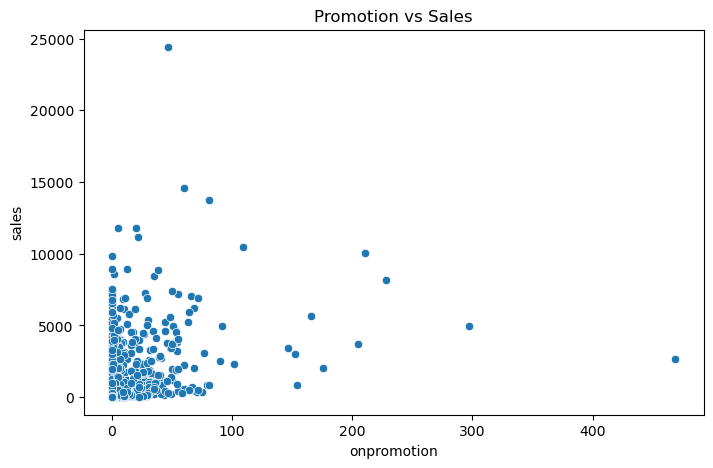

In [48]:
promotion_sales = df.groupby(
    'onpromotion'
)['sales'].mean()

print(promotion_sales.head())

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='onpromotion',
    y='sales',
    data=df.sample(5000)
)

plt.title('Promotion vs Sales')

plt.show()

scatter plot is used for more insightful information and yes the more the promotion the higher the sales

7. transaction vs sales
do more customers lead to more sales

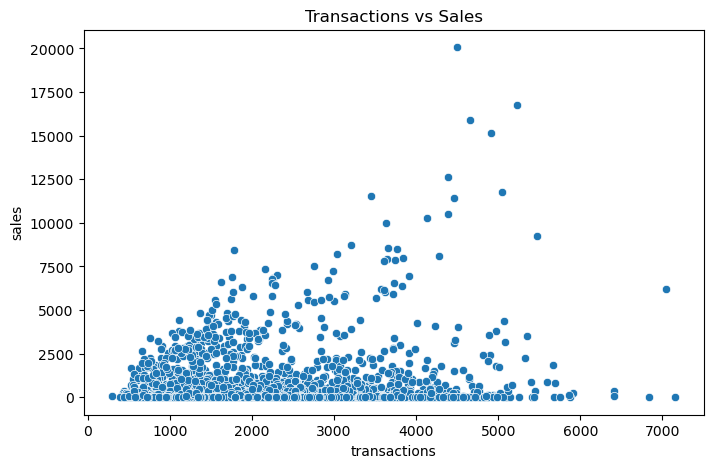

In [49]:
df[['transactions','sales']].corr()
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='transactions',
    y='sales',
    data=df.sample(5000)
)

plt.title('Transactions vs Sales')

plt.show()

since the dots does move upwards it shows that more transaction brings more sales


FEATURE SELECTION

we are performing feature engineering here which is basically expanding and creating more columns

for eg lets take the date 25/12/26
we know that its christmas, a holiday season, might be a weekend, so the sales might increase but for the model its just a normal date

so we split them into more columns like day date month year weeday/weekend etc for more clear business outcomes and learn patterns

In [54]:
# step 1 YEAR
df['year'] = df['date'].dt.year
df.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,type_y,locale,locale_name,description,transferred,transactions,dcoilwtico,month,is_holiday,year
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14,1,1,2013
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14,1,1,2013
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14,1,1,2013
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14,1,1,2013
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,Holiday,National,Ecuador,Primer dia del ano,False,NaN,93.14,1,1,2013


we can see that a new column that is year has been added

In [55]:
#step 2 MONTH
df['month'] = df['date'].dt.month

In [56]:
#step 3 DAY
df['day'] = df['date'].dt.day

In [57]:
#step 4 day of week mon-0 tue -1
df['day_of_week'] = df['date'].dt.dayofweek

In [ ]:
#step 5 quarter (1-4)
#which quarter gives more profit or sales
df['quarter'] = df['date'].dt.quarter

In [59]:
#step 6 week of year
df['week_of_year'] = df['date'].dt.isocalendar().week

In [60]:
#week end or not
df['is_weekend'] = (
    df['day_of_week']
    .isin([5,6])
    .astype(int)
)

In [61]:
#checking
df[['date',
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter',
    'week_of_year',
    'is_weekend']].head()

,date,year,month,day,day_of_week,quarter,week_of_year,is_weekend
0,2013-01-01,2013,1,1,1,1,1,0
1,2013-01-01,2013,1,1,1,1,1,0
2,2013-01-01,2013,1,1,1,1,1,0
3,2013-01-01,2013,1,1,1,1,1,0
4,2013-01-01,2013,1,1,1,1,1,0


ENCODING

This is the process we talked about earlier where the object data type is converted into int and float

the main objective is to convert the text into numericals 

In [62]:
df.select_dtypes(include='object').columns

Index(['family', 'city', 'state', 'type_x', 'type_y', 'locale', 'locale_name',
       'description', 'transferred'],
      dtype='object')

this shows that all these columns contains object data types and should be converted into a reasonable numerical format

In [ ]:
#sample for one column
le = LabelEncoder()
df['family'] = le.fit_transform(df['family'])

here the encoder looks at unique values and sorts them in ascending order. then they further apply numbers like 1,2,3 etc for each unique column in the data
(converting text into numbers)

In [64]:
df['family'].head()

0    0
1    1
2    2
3    3
4    4
Name: family, dtype: int64

this is for the example of how an encoder would work but we have to perform this function on all the columns in the data set

In [ ]:
#for all the columns

In [ ]:


le = LabelEncoder()
#gets all the columns that includes objects
#uses loop for getting one col at a time
for col in df.select_dtypes(include='object').columns:
    #[col] refers family, city, etc... one at a time
    df[col] = le.fit_transform(
        df[col].astype(str)#everything converted to text format ie string
    )

In [ ]:
#checking info if everything is applied properly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3054348 entries, 0 to 3054347
Data columns (total 25 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        int64         
 4   sales         float64       
 5   onpromotion   int64         
 6   city          int64         
 7   state         int64         
 8   type_x        int64         
 9   cluster       int64         
 10  type_y        int64         
 11  locale        int64         
 12  locale_name   int64         
 13  description   int64         
 14  transferred   int64         
 15  transactions  float64       
 16  dcoilwtico    float64       
 17  month         int32         
 18  is_holiday    int64         
 19  year          int32         
 20  day           int32         
 21  day_of_week   int32         
 22  quarter       int32         
 23  week_of_year  UInt32        
 24

we can see that all the data type given is either int or float format

from this point onwards all the data cleaning and eda are done and we are entering into the ml pipeline
FEATURE SELECTION

so in the feature selection process we need the inputs and the outputs.

well take the inputs as the various columns like city, family, promotion etc and take the output as sales

because from our pov and as well as a business pov we have to look at the sales in order to define if the revenue is a profit or a loss by comparing with the past details.

In [69]:
#1. as the first step, let us look at the available columns first
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type_x', 'cluster', 'type_y', 'locale', 'locale_name',
       'description', 'transferred', 'transactions', 'dcoilwtico', 'month',
       'is_holiday', 'year', 'day', 'day_of_week', 'quarter', 'week_of_year',
       'is_weekend'],
      dtype='object')

we are going to generate the input data set first
in order to do that we are dropping the sales col from the other columns
so that by dropping sales (output) we'll get all the input factors

also we drop date because we did feature eng and seperated them as date day month year week etc

In [70]:
X = df.drop(['sales', 'date'], axis=1)

In [97]:
#creating output variable
y = df['sales']

In [98]:
print(X.columns) #shows inputs
print(y)# shows output


Index(['id', 'store_nbr', 'family', 'onpromotion', 'city', 'state', 'type_x',
       'cluster', 'type_y', 'locale', 'locale_name', 'description',
       'transferred', 'transactions', 'dcoilwtico', 'month', 'is_holiday',
       'year', 'day', 'day_of_week', 'quarter', 'week_of_year', 'is_weekend'],
      dtype='object')
0             0.000
1             0.000
2             0.000
3             0.000
4             0.000
             ...   
3054343     438.133
3054344     154.553
3054345    2419.729
3054346     121.000
3054347      16.000
Name: sales, Length: 3054348, dtype: float64


In [106]:
print(X.shape)
print(y.shape)

(3054348, 23)
(3054348,)


The input has 23 cols and the output is just one col so no second value is mentioned

In [107]:
#reducing sample size
df_sample = df.sample(
    n=300000,
    random_state=42
)

In [108]:
X = df_sample.drop(
    ['sales', 'date'],
    axis=1
)

y = df_sample['sales']

In [109]:
print(X.shape)
print(y.shape)

(300000, 23)
(300000,)


10. TRAIN TEST SPLIT

In [110]:
#splitting
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #20 percent test data
    random_state=42
)

In [101]:
print(X_train.shape)
print(X_test.shape)

(2443478, 23)
(610870, 23)


11. MODEL BUILDING
we use random forest as we have large amount of data and it is used to handle non linear relationships

In [ ]:
'''#choosing model with parameters
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=50,#50 decision trees
    max_depth=15,#prevents extremely large trees
    random_state=42,
    n_jobs=-1#all cpu runs
)
'''

In [ ]:
'''#learning train

rf.fit(X_train, y_train)
'''

RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1, random_state=42)

#n_estimators
Random Forest creates many decision trees.
Example:
Tree 1 predicts 500
Tree 2 predicts 520
Tree 3 predicts 490

Final prediction:(500+520+490)/3
≈ 503

the model training is the major stage. here the model learns thousands of patters by using the train data set

for eg
Store 1
December
Promotion = Yes
then High Sales

Store 2
February
Promotion = No

then Lower Sales

 we saw earlier in the graphical representation that if the store has promotions then the sales are increased comparitively
 in the eg we took since the second store did not have promotion, it might have led to lower sales

 like this the model will learn multiple patterns to predict the output

first we have perform traditional train_test_split 

12. Make predictions
now since the model is trained it is given to make predictions based on the data and patterns that it has learnt

eg
The model now sees:
inputs:
Store = 3
Month = 12
Promotion = 10
Transactions = 200

and predicts:
output:
Sales = 780

In [ ]:
'''#prediction
pred = rf.predict(X_test)
'''

In [ ]:
'''#view prediction
print(pred[:10])
'''

[ 318.2920313  1383.57285944    5.83722548   43.34571004    1.42284718
 1247.06389493  659.32080601   13.60801774  396.59957626   13.65535162]


In [ ]:
'''#comparision of actual vs predicted to find out the model accuracy
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})

comparison.head()
'''

,Actual,Predicted
1588578,296.531,318.292031
334711,1262.000,1383.572859
2915709,7.000,5.837225
1416903,26.000,43.345710
1821026,0.000,1.422847


TIME BASED SPLIT
first we performed the normal tradition train test split method but in case of sales forecasting, we have to predict the future data with present info

but train test split assign the training and testing data randomly

eg: we are currently in 2026 and if the train has 2023,2024 and asks to predict 2025 sales obviously its gotta be right as we are currently in 2026 and have the data for 2025 already

the usual method is to predict the sales for 2026 with prev year data like 2025,2024,2023....

so therefore time based split is used
here we take train data as 2023,2024,2025 and test data as 2026

so that the previous year data are used to predict the future outcome

In [154]:
#time based
df_sample = df.sample(
    n=300000,
    random_state=42
)
#sort values by date
df_sample = df_sample.sort_values('date')

#create train test dataset
train_data = df_sample[
    df_sample['date'] < '2017-01-01'
]

test_data = df_sample[
    df_sample['date'] >= '2017-01-01'
]

#create x_train and y_train
X_train = train_data.drop(
    ['sales', 'date', 'id'],
    axis=1
)
y_train = train_data['sales']

#test data

X_test = test_data.drop(
    ['sales', 'date', 'id'],
    axis=1
)

y_test = test_data['sales']

In [166]:
#train using time split
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

In [167]:
#train model
import time

start = time.time()

rf.fit(X_train, y_train)

end = time.time()

print(
    "Training Time:",
    round(end-start,2),
    "seconds"
)

Training Time: 28.14 seconds


13. EVALUATE THE MODEL
now we got the answer for the actual vs predicted values and now we evaluate the model by using error detection methods like

1. mean absolute error
2. rmse
3. r^2

In [168]:
#time based split pred
pred = rf.predict(X_test)

In [169]:
#comparision  of actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': pred
})

comparison.head(10)

,Actual,Predicted
2642956,0.0,0.057549
2643335,0.0,0.000360
2644258,0.0,0.000000
2643186,0.0,0.049036
2642936,0.0,0.004121
2644418,0.0,72.563781
2642994,0.0,0.027114
2643167,0.0,0.004121
2644470,0.0,11.141465
2643053,0.0,0.001440


In [170]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [171]:
#MAE
mae = mean_absolute_error(
    y_test,
    pred
)

print("MAE:", mae)

MAE: 92.58097923179304


MAE is the avg error and shows on how much average the actual and predicted values are different

eg: if the answer is 20
the predictions are off by an average of 20 units

In [172]:
#RMSE
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("RMSE:", rmse)

RMSE: 355.92150296008754


The RMSE is used to indicate the large error or huge mistakes if the model accuracy is off by 100 or so units

In [173]:
#R^2
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    pred
)

print("R² Score:", r2)

R² Score: 0.9333522376771588


r^2 shows the accuracy of the model in the means of 0-terrible
0.5-decent
0.8+ - very good
explains within a range of 0-1

14.FEATURE IMPORTANCE
this phase answers which features influence the sales the most from the given input data ie the columns

In [174]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})


In [175]:
#sorting values in ascending order
importance = importance.sort_values(
    by='Importance',
    ascending=False
)

In [176]:
#view the result of imporant features
print(importance.head(10))
#shows the top features and their importance accordingly
#therefore we can agree that whichever feature comes at the top influences the sales the most


         Feature  Importance
1         family    0.417666
12  transactions    0.239097
2    onpromotion    0.208204
16          year    0.029578
20  week_of_year    0.014461
0      store_nbr    0.014002
6        cluster    0.013888
13    dcoilwtico    0.013030
14         month    0.009614
18   day_of_week    0.008387


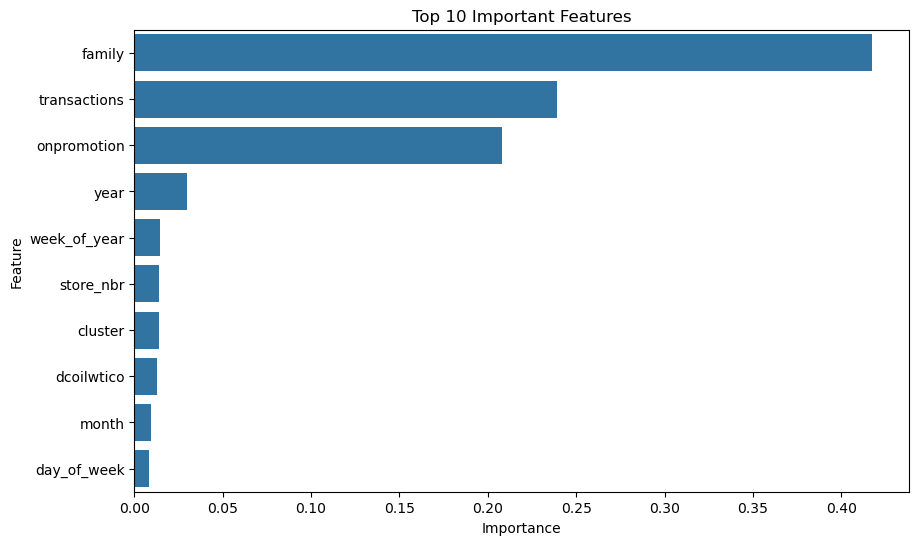

In [177]:
#visualize the top features
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Important Features')

plt.show()

INSIGHTS
by getting the results the model performed on large data sets and the following results are obtained

- the r^2 error calculation method showed highest accuracy of about 91.84% showing excellent predictive performance

- also the family feature has contributed most to the sales on the overall folowed by transactions and on promotions